Importing Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics #--> evaluate the mode find accuracy and error ratio

Data collection & processing

In [2]:
gold_data = pd.read_csv("D:\Python To ML All Work\gld_price_data.csv")
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [25]:
gold_data.shape
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [26]:
gold_data.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

Getting the statistical of data 

In [27]:
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Correlation
positive correlation
negative correlation

In [28]:
import pandas as pd

gold_data["Date"] = pd.to_datetime(gold_data["Date"])

In [29]:
correlation = gold_data.corr()

constructing heatmap to understand correlation

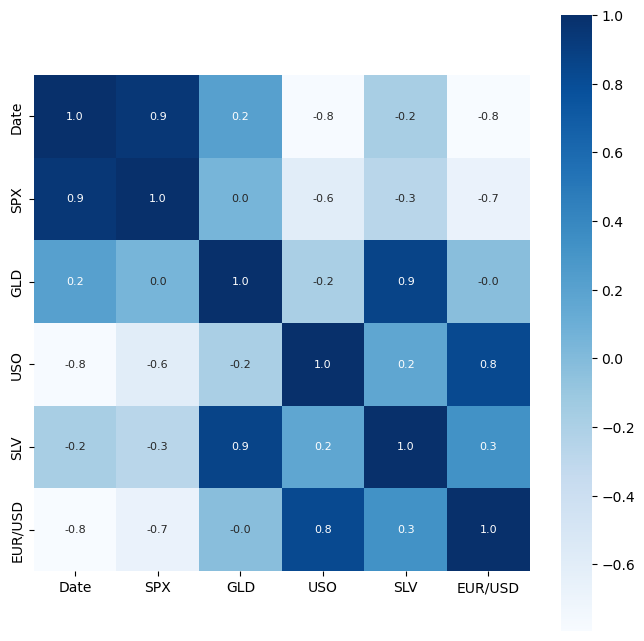

In [30]:
plt.figure(figsize=(8, 8))

sns.heatmap(
    correlation,
    cbar=True,
    square=True,
    fmt=".1f",
    annot=True,
    annot_kws={"size": 8},
    cmap="Blues"
)

plt.show()

In [31]:
print(correlation["GLD"])

Date       0.209118
SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


Check the distribution of the GLD price

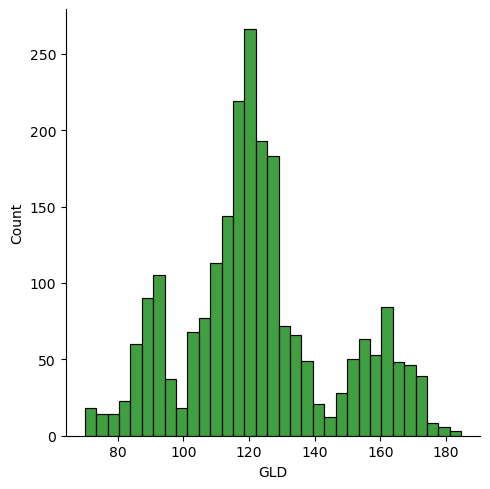

In [32]:
sns.displot(gold_data["GLD"],color='green')

splitting the features and target

In [33]:
x = gold_data.drop(["Date","GLD"],axis=1)
y = gold_data["GLD"]
print(x)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [34]:
print(y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


splitting into training and testing data

In [35]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=2)

MOdel Training : Random Forest regression

In [36]:
regressor = RandomForestRegressor(n_estimators=100)

In [37]:
regressor.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Model Evaluation

In [38]:
x_test_predication = regressor.predict(x_test)
print(x_test_predication)

[168.79149995  81.78550007 115.96790021 127.71820078 120.85520123
 154.78279767 150.41959834 126.16700037 117.4931986  125.94620012
 116.64370114 171.30780075 141.78669944 167.78419781 115.19660021
 117.71210047 137.98790359 170.05500067 159.66620353 159.30409993
 155.15920006 125.22549998 176.16820002 157.46950395 125.2591003
  93.84620001  77.45579985 120.21999997 119.04929922 167.4742999
  88.16700052 125.31040021  90.95630061 117.56390046 121.13939925
 136.40790032 115.27000128 115.36900059 147.69229871 107.46690106
 103.59010217  87.27119791 126.45350073 117.95480032 151.8070992
 119.50040018 108.35139969 108.10439856  93.14560043 127.20609739
  74.89400034 113.64189912 121.20530033 111.40069928 118.80629882
 121.19379944 158.42280097 167.03850142 147.18849683  85.96069878
  94.60880034  86.80529874  90.59410049 118.94550083 126.40460075
 127.51150017 169.14799955 122.31369944 117.37489899  98.47500049
 167.81840059 142.78079874 131.55790228 121.27700233 121.32079979
 119.77990056

R squared error

In [39]:
error_score = metrics.r2_score(y_test,x_test_predication)
print("R Squared error : ",error_score)

R Squared error :  0.9890641820261719


Compare the actual value and predicated values

In [40]:
y_test = list(y_test)

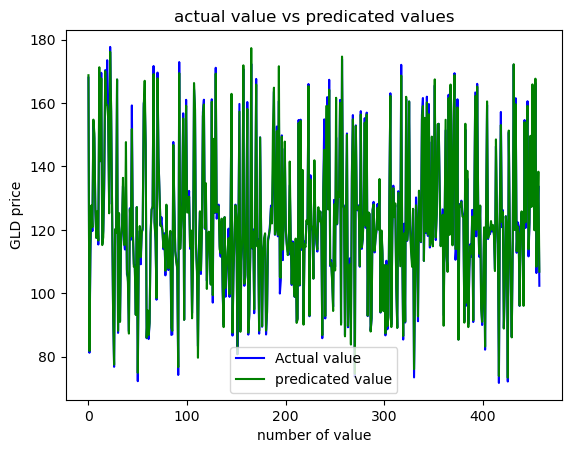

In [41]:
plt.plot(y_test, color = "blue", label = "Actual value")
plt.plot(x_test_predication, color = "green", label = "predicated value")
plt.title("actual value vs predicated values")
plt.xlabel("number of value")
plt.ylabel("GLD price")
plt.legend()
plt.show()